# Person and Head Detection: Dataset Check and Scratch Model

**Student:** Arjun Bishnoi

We check the Person Detection with Head dataset and train a small detection model from scratch. The goal is to find heads and people in an image.

Dataset: [Person Detection with Head, version 2](https://universe.roboflow.com/person-xf2dz/person-detection-with-head-8aw41/dataset/2)  
Format: YOLOv8  

In [1]:
from pathlib import Path
from collections import Counter
import copy
import math
import platform
import random
import time
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
from PIL import Image, ImageDraw
from IPython.display import Markdown, display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

CLASS_NAMES = ["Head", "Person"]
COLORS = [(40, 110, 240), (30, 180, 80)]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}


## 1. Dataset setup

The downloaded Roboflow ZIP is expected to be in the same project folder. It is extracted only if the dataset folder is not already present.


In [3]:
ZIP_PATH = Path("Person Detection with head.v2i.yolov8.zip")
DATASET_ROOT = Path("Person Detection with head.v2i.yolov8")

if not (DATASET_ROOT / "data.yaml").exists():
    if not ZIP_PATH.exists():
        raise FileNotFoundError("Dataset folder and ZIP were not found.")
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_file:
        zip_file.extractall(DATASET_ROOT)
    print("Dataset extracted.")
else:
    print("Dataset folder found.")

print("Dataset path:", DATASET_ROOT)


Dataset folder found.
Dataset path: Person Detection with head.v2i.yolov8


## 2. Split counts and image-label matching


In [4]:
def files_for_split(split):
    image_dir = DATASET_ROOT / split / "images"
    label_dir = DATASET_ROOT / split / "labels"
    images = sorted(
        path for path in image_dir.iterdir()
        if path.suffix.lower() in IMAGE_EXTENSIONS
    )
    labels = sorted(label_dir.glob("*.txt"))
    return images, labels


split_rows = []
split_pairs = {}

for split in ["train", "valid", "test"]:
    images, labels = files_for_split(split)
    image_by_name = {path.stem: path for path in images}
    label_by_name = {path.stem: path for path in labels}
    matching_names = sorted(image_by_name.keys() & label_by_name.keys())

    split_pairs[split] = [
        (image_by_name[name], label_by_name[name])
        for name in matching_names
    ]
    split_rows.append({
        "split": split,
        "images": len(images),
        "labels": len(labels),
        "matched_pairs": len(matching_names),
        "images_without_label": len(image_by_name.keys() - label_by_name.keys()),
        "labels_without_image": len(label_by_name.keys() - image_by_name.keys()),
    })

split_table = pd.DataFrame(split_rows)
split_table


,split,images,labels,matched_pairs,images_without_label,labels_without_image
0,train,12231,12231,12231,0,0
1,valid,899,899,899,0,0
2,test,846,846,846,0,0


## 3. Label and box checks

A normal YOLO box has five values: class, centre x, centre y, width and height. The values should be between 0 and 1, and the box should stay inside the image.


In [5]:
def read_yolo_label(label_path):
    boxes = []
    issues = []

    lines = label_path.read_text(encoding="utf-8").splitlines()
    for line_number, line in enumerate(lines, start=1):
        parts = line.strip().split()
        if not parts:
            continue
        if len(parts) > 5:
            issues.append((line_number, "more than 5 values; looks like a polygon label"))
            continue
        if len(parts) != 5:
            issues.append((line_number, "expected 5 values"))
            continue

        try:
            values = [float(value) for value in parts]
        except ValueError:
            issues.append((line_number, "non-numeric value"))
            continue

        if not all(math.isfinite(value) for value in values):
            issues.append((line_number, "non-finite value"))
            continue

        class_value, centre_x, centre_y, width, height = values
        if not class_value.is_integer() or int(class_value) not in range(len(CLASS_NAMES)):
            issues.append((line_number, "invalid class id"))
            continue

        values_in_range = (
            0 <= centre_x <= 1
            and 0 <= centre_y <= 1
            and 0 < width <= 1
            and 0 < height <= 1
        )
        if not values_in_range:
            issues.append((line_number, "values outside the YOLO range"))
            continue

        x1, y1 = centre_x - width / 2, centre_y - height / 2
        x2, y2 = centre_x + width / 2, centre_y + height / 2
        if x1 < -1e-6 or y1 < -1e-6 or x2 > 1 + 1e-6 or y2 > 1 + 1e-6:
            issues.append((line_number, "box crosses the image boundary"))
            continue

        boxes.append((int(class_value), centre_x, centre_y, width, height))

    return boxes, issues


In [6]:
class_rows = []
issue_rows = []
empty_label_rows = []

for split, pairs in split_pairs.items():
    counts = Counter()
    empty_count = 0

    for _, label_path in pairs:
        boxes, issues = read_yolo_label(label_path)
        if not label_path.read_text(encoding="utf-8").strip():
            empty_count += 1

        for class_id, *_ in boxes:
            counts[class_id] += 1

        for line_number, issue in issues:
            issue_rows.append({
                "split": split,
                "label_file": label_path.name,
                "line": line_number,
                "issue": issue,
            })

    for class_id, class_name in enumerate(CLASS_NAMES):
        class_rows.append({
            "split": split,
            "class": class_name,
            "boxes": counts[class_id],
        })
    empty_label_rows.append({
        "split": split,
        "empty_label_files": empty_count,
    })

class_table = pd.DataFrame(class_rows)
issues_table = pd.DataFrame(
    issue_rows,
    columns=["split", "label_file", "line", "issue"],
)
empty_table = pd.DataFrame(empty_label_rows)

display(class_table.pivot(index="split", columns="class", values="boxes"))
display(empty_table)
print("Lines that did not contain a normal box:", len(issues_table))
display(issues_table.head(10))


class,Head,Person
split,,
test,3812,4141
train,54310,60969
valid,4145,4791


,split,empty_label_files
0,train,264
1,valid,18
2,test,20


Lines that did not contain a normal box: 139


,split,label_file,line,issue
0,train,screenshot_20_png.rf.54aa0ca73ce38d2a173ed7ce7...,3,more than 5 values; looks like a polygon label
1,train,screenshot_20_png.rf.a3b7de1e7bd66536d3601a579...,3,more than 5 values; looks like a polygon label
2,train,screenshot_20_png.rf.e42a9e8714285a95a9202d4e6...,3,more than 5 values; looks like a polygon label
3,train,screenshot_22_png.rf.3f8653cf6f35aa74925cbad3d...,2,more than 5 values; looks like a polygon label
4,train,screenshot_22_png.rf.3f8653cf6f35aa74925cbad3d...,3,more than 5 values; looks like a polygon label
5,train,screenshot_22_png.rf.5e3360ee17ad110d3345bcd3e...,2,more than 5 values; looks like a polygon label
6,train,screenshot_22_png.rf.5e3360ee17ad110d3345bcd3e...,3,more than 5 values; looks like a polygon label
7,train,screenshot_22_png.rf.621a1c7931abd488dddd0fd34...,2,more than 5 values; looks like a polygon label
8,train,screenshot_22_png.rf.621a1c7931abd488dddd0fd34...,3,more than 5 values; looks like a polygon label
9,train,screenshot_44_png.rf.28e711809e8fc9d9852db82bf...,1,more than 5 values; looks like a polygon label


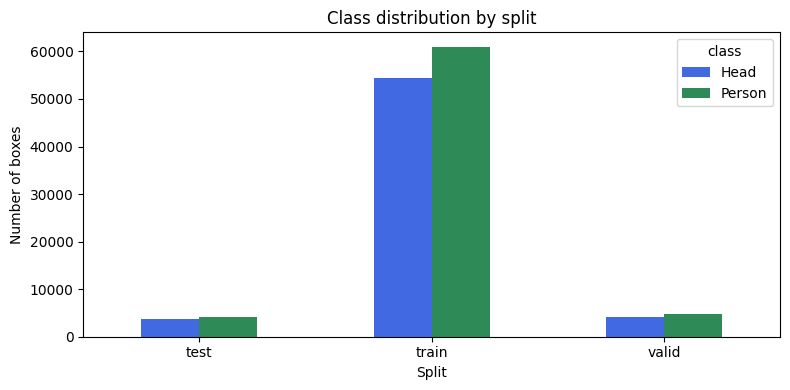

In [7]:
distribution = class_table.pivot(index="split", columns="class", values="boxes")
distribution.plot(kind="bar", figsize=(8, 4), color=["royalblue", "seagreen"])
plt.title("Class distribution by split")
plt.xlabel("Split")
plt.ylabel("Number of boxes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [8]:
def count_boxes_kept_by_grid(grid_size):
    rows = []
    for split, pairs in split_pairs.items():
        total_boxes = 0
        kept_boxes = 0

        for _, label_path in pairs:
            boxes, _ = read_yolo_label(label_path)
            used_cells = set()
            total_boxes += len(boxes)

            for _, centre_x, centre_y, _, _ in boxes:
                grid_x = min(int(centre_x * grid_size), grid_size - 1)
                grid_y = min(int(centre_y * grid_size), grid_size - 1)
                used_cells.add((grid_x, grid_y))

            kept_boxes += len(used_cells)

        skipped_boxes = total_boxes - kept_boxes
        rows.append({
            "grid": f"{grid_size} x {grid_size}",
            "split": split,
            "valid_boxes": total_boxes,
            "boxes_kept": kept_boxes,
            "boxes_skipped": skipped_boxes,
            "skipped_percent": round(
                100 * skipped_boxes / max(total_boxes, 1), 2
            ),
        })
    return rows


grid_check_table = pd.DataFrame(
    count_boxes_kept_by_grid(8)
    + count_boxes_kept_by_grid(10)
    + count_boxes_kept_by_grid(16)
)
display(grid_check_table)


,grid,split,valid_boxes,boxes_kept,boxes_skipped,skipped_percent
0,8 x 8,train,115279,81405,33874,29.38
1,8 x 8,valid,8936,6106,2830,31.67
2,8 x 8,test,7953,5706,2247,28.25
3,10 x 10,train,115279,89979,25300,21.95
4,10 x 10,valid,8936,6739,2197,24.59
5,10 x 10,test,7953,6285,1668,20.97
6,16 x 16,train,115279,103062,12217,10.60
7,16 x 16,valid,8936,7865,1071,11.99
8,16 x 16,test,7953,7195,758,9.53


### Dataset summary

- All 13,976 images have matching labels.
- Head and Person boxes are fairly balanced.
- There are 302 empty label files.
- The 139 polygon labels are skipped because this model uses boxes.
- A 16 x 16 grid keeps more boxes in crowded images.


## 4. Annotated dataset samples

Blue boxes show heads and green boxes show people.


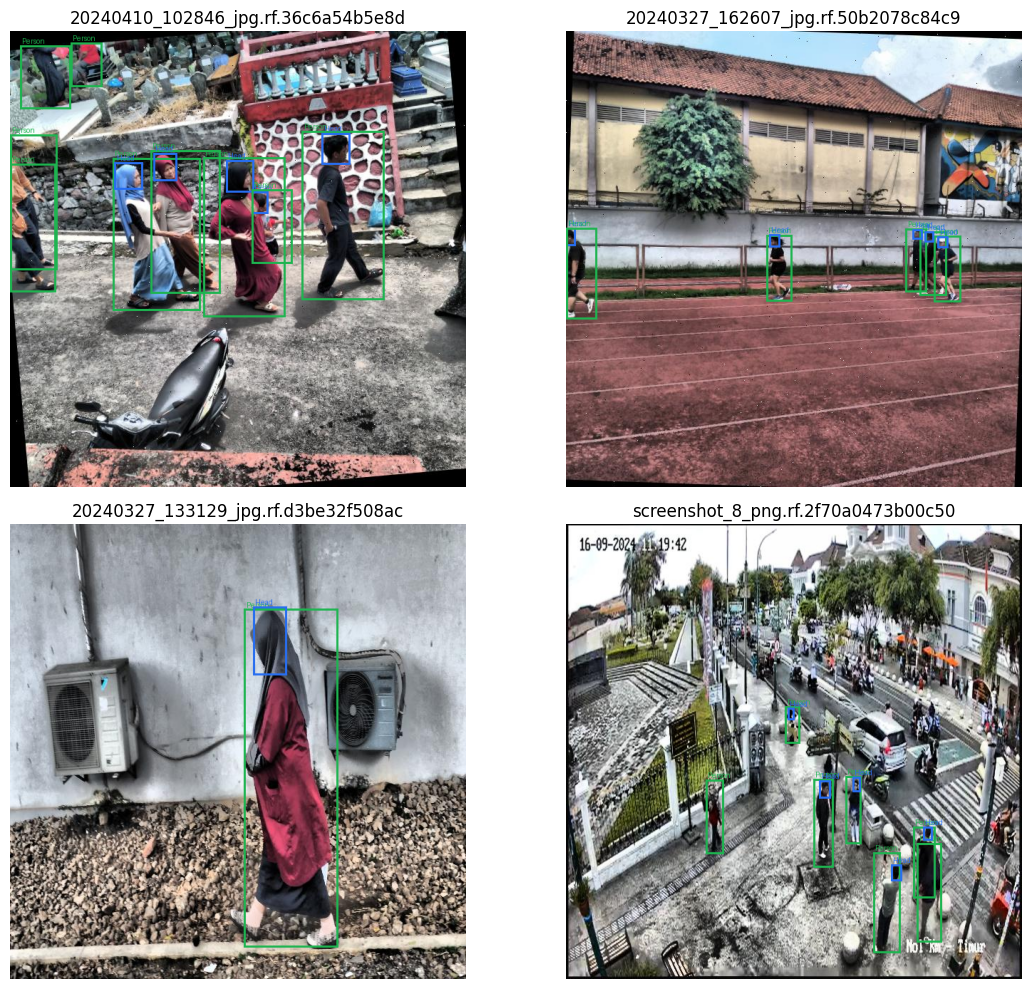

In [9]:
def draw_yolo_boxes(image_path, label_path):
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    boxes, _ = read_yolo_label(label_path)

    for class_id, centre_x, centre_y, width, height in boxes:
        x1 = (centre_x - width / 2) * image.width
        y1 = (centre_y - height / 2) * image.height
        x2 = (centre_x + width / 2) * image.width
        y2 = (centre_y + height / 2) * image.height
        color = COLORS[class_id]
        draw.rectangle((x1, y1, x2, y2), outline=color, width=3)
        draw.text((x1 + 3, max(0, y1 - 12)), CLASS_NAMES[class_id], fill=color)

    return image


sample_pairs = random.Random(SEED).sample(split_pairs["train"], 4)
figure, axes = plt.subplots(2, 2, figsize=(12, 10))

for axis, (image_path, label_path) in zip(axes.ravel(), sample_pairs):
    axis.imshow(draw_yolo_boxes(image_path, label_path))
    axis.set_title(image_path.name[:35])
    axis.axis("off")

plt.tight_layout()
plt.show()


## 5. Preprocessing and model plan

Roboflow resized and augmented the original images. In this notebook, we:

- resize images to 256 x 256;
- normalize pixels to 0-1;
- randomly flip training images;
- use all three dataset splits; and
- train a scratch model with a 16 x 16 grid.


In [10]:
IMG_SIZE = 256
GRID_SIZE = 16
BATCH_SIZE = 32
EPOCHS = 25
MIN_EPOCHS = 12
EARLY_STOPPING_PATIENCE = 5
LEARNING_RATE = 1e-3
NO_OBJECT_WEIGHT = 1.25


class HeadPersonDataset(Dataset):
    def __init__(self, pairs, seed=42, use_flip=False):
        self.pairs = list(pairs)
        random.Random(seed).shuffle(self.pairs)
        self.use_flip = use_flip

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        image_path, label_path = self.pairs[index]
        image = Image.open(image_path).convert("RGB")
        boxes, _ = read_yolo_label(label_path)

        if self.use_flip and random.random() < 0.5:
            image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
            boxes = [
                (class_id, 1 - centre_x, centre_y, width, height)
                for class_id, centre_x, centre_y, width, height in boxes
            ]

        image = image.resize((IMG_SIZE, IMG_SIZE))
        image_array = np.array(image, dtype=np.float32) / 255.0
        image_tensor = torch.from_numpy(image_array).permute(2, 0, 1)

        target = torch.zeros(
            (5 + len(CLASS_NAMES), GRID_SIZE, GRID_SIZE),
            dtype=torch.float32,
        )

        for class_id, centre_x, centre_y, width, height in boxes:
            grid_x = min(int(centre_x * GRID_SIZE), GRID_SIZE - 1)
            grid_y = min(int(centre_y * GRID_SIZE), GRID_SIZE - 1)
            if target[4, grid_y, grid_x] == 1:
                continue

            target[0, grid_y, grid_x] = centre_x * GRID_SIZE - grid_x
            target[1, grid_y, grid_x] = centre_y * GRID_SIZE - grid_y
            target[2, grid_y, grid_x] = width
            target[3, grid_y, grid_x] = height
            target[4, grid_y, grid_x] = 1
            target[5 + class_id, grid_y, grid_x] = 1

        return image_tensor, target


In [11]:
train_dataset = HeadPersonDataset(split_pairs["train"], seed=42, use_flip=True)
val_dataset = HeadPersonDataset(split_pairs["valid"], seed=123)
test_dataset = HeadPersonDataset(split_pairs["test"], seed=321)

loader_generator = torch.Generator().manual_seed(SEED)
use_pinned_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=use_pinned_memory,
    generator=loader_generator,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=use_pinned_memory,
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))


Training images: 12231
Validation images: 899
Test images: 846


In [12]:
def conv_block(input_channels, output_channels, dropout=0.1):
    return nn.Sequential(
        nn.Conv2d(input_channels, output_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(output_channels),
        nn.ReLU(),
        nn.Dropout2d(dropout),
        nn.MaxPool2d(2),
    )


class ScratchDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
        )
        self.head = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.1),
            nn.Conv2d(256, 5 + len(CLASS_NAMES), kernel_size=1),
        )

    def forward(self, images):
        return self.head(self.backbone(images))


def scratch_loss(prediction, target):
    object_mask = target[:, 4]
    empty_mask = 1 - object_mask
    object_count = object_mask.sum().clamp(min=1)
    empty_count = empty_mask.sum().clamp(min=1)

    predicted_box = torch.sigmoid(prediction[:, 0:4])
    predicted_object = torch.sigmoid(prediction[:, 4])
    predicted_class = torch.softmax(prediction[:, 5:], dim=1)

    box_loss = (
        ((predicted_box - target[:, 0:4]) ** 2)
        * object_mask.unsqueeze(1)
    ).sum() / object_count
    object_loss = (
        ((predicted_object - 1) ** 2) * object_mask
    ).sum() / object_count
    empty_loss = (
        (predicted_object ** 2) * empty_mask
    ).sum() / empty_count
    class_loss = (
        ((predicted_class - target[:, 5:]) ** 2)
        * object_mask.unsqueeze(1)
    ).sum() / object_count

    return (
        5 * box_loss
        + object_loss
        + NO_OBJECT_WEIGHT * empty_loss
        + class_loss
    )


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ScratchDetector().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
)
use_mixed_precision = device.type == "cuda"
gradient_scaler = torch.amp.GradScaler("cuda", enabled=use_mixed_precision)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
model_size_mb = parameter_count * 4 / 1024**2
total_ram_gb = psutil.virtual_memory().total / 1024**3

print("Device:", device)
print("PyTorch version:", torch.__version__)
print("CUDA version used by PyTorch:", torch.version.cuda)
print("Python version:", platform.python_version())
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory (GB):",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2,
        ),
    )
else:
    print("Processor:", platform.processor() or "CPU")
print("System RAM (GB):", round(total_ram_gb, 2))
print("Trainable parameters:", f"{parameter_count:,}")
print("Approximate model size (MB):", round(model_size_mb, 2))
print("Mixed precision enabled:", use_mixed_precision)


Device: cuda
PyTorch version: 2.13.0+cu126
CUDA version used by PyTorch: 12.6
Python version: 3.13.9
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
GPU memory (GB): 8.0
System RAM (GB): 31.42
Trainable parameters: 981,767
Approximate model size (MB): 3.75
Mixed precision enabled: True


## 6. Training

The best model is saved using validation loss. The learning rate is reduced when improvement slows.


In [14]:
history = {"train_loss": [], "val_loss": [], "learning_rate": []}
best_validation_loss = float("inf")
best_epoch = 0
best_model_state = None
epochs_without_improvement = 0
process = psutil.Process()
memory_before_mb = process.memory_info().rss / 1024**2

if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()

training_start = time.perf_counter()

for epoch in range(EPOCHS):
    model.train()
    train_total = 0.0

    for images, targets in train_loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type=device.type,
            enabled=use_mixed_precision,
        ):
            loss = scratch_loss(model(images), targets)

        gradient_scaler.scale(loss).backward()
        gradient_scaler.step(optimizer)
        gradient_scaler.update()
        train_total += loss.item() * images.size(0)

    model.eval()
    validation_total = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            with torch.amp.autocast(
                device_type=device.type,
                enabled=use_mixed_precision,
            ):
                validation_loss_value = scratch_loss(
                    model(images), targets
                )

            validation_total += (
                validation_loss_value.item() * images.size(0)
            )

    train_loss = train_total / len(train_dataset)
    validation_loss = validation_total / len(val_dataset)
    scheduler.step(validation_loss)
    current_learning_rate = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(validation_loss)
    history["learning_rate"].append(current_learning_rate)

    if validation_loss < best_validation_loss - 1e-4:
        best_validation_loss = validation_loss
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} - "
        f"train loss: {train_loss:.4f} - "
        f"validation loss: {validation_loss:.4f} - "
        f"learning rate: {current_learning_rate:.6f}"
    )

    enough_epochs_completed = epoch + 1 >= MIN_EPOCHS
    if (
        enough_epochs_completed
        and epochs_without_improvement >= EARLY_STOPPING_PATIENCE
    ):
        print("Stopping early because validation did not improve.")
        break

training_seconds = time.perf_counter() - training_start
memory_after_mb = process.memory_info().rss / 1024**2
epochs_completed = len(history["train_loss"])
model.load_state_dict(best_model_state)

if device.type == "cuda":
    peak_gpu_memory_gb = torch.cuda.max_memory_allocated() / 1024**3
else:
    peak_gpu_memory_gb = 0.0

print("Epochs completed:", epochs_completed)
print("Best epoch:", best_epoch)
print("Best validation loss:", round(best_validation_loss, 4))
print("Training time (minutes):", round(training_seconds / 60, 2))
print("Program memory before training (MB):", round(memory_before_mb, 1))
print("Program memory after training (MB):", round(memory_after_mb, 1))
if device.type == "cuda":
    print("Peak GPU memory used (GB):", round(peak_gpu_memory_gb, 2))


Epoch 01/25 - train loss: 1.2970 - validation loss: 1.0692 - learning rate: 0.001000
Epoch 02/25 - train loss: 1.0126 - validation loss: 0.8962 - learning rate: 0.001000
Epoch 03/25 - train loss: 0.9111 - validation loss: 0.8553 - learning rate: 0.001000
Epoch 04/25 - train loss: 0.8492 - validation loss: 0.7883 - learning rate: 0.001000
Epoch 05/25 - train loss: 0.7972 - validation loss: 0.7552 - learning rate: 0.001000
Epoch 06/25 - train loss: 0.7628 - validation loss: 0.7471 - learning rate: 0.001000
Epoch 07/25 - train loss: 0.7291 - validation loss: 0.7183 - learning rate: 0.001000
Epoch 08/25 - train loss: 0.7058 - validation loss: 0.7239 - learning rate: 0.001000
Epoch 09/25 - train loss: 0.6885 - validation loss: 0.7090 - learning rate: 0.001000
Epoch 10/25 - train loss: 0.6665 - validation loss: 0.6919 - learning rate: 0.001000
Epoch 11/25 - train loss: 0.6504 - validation loss: 0.6985 - learning rate: 0.001000
Epoch 12/25 - train loss: 0.6341 - validation loss: 0.6933 - lear

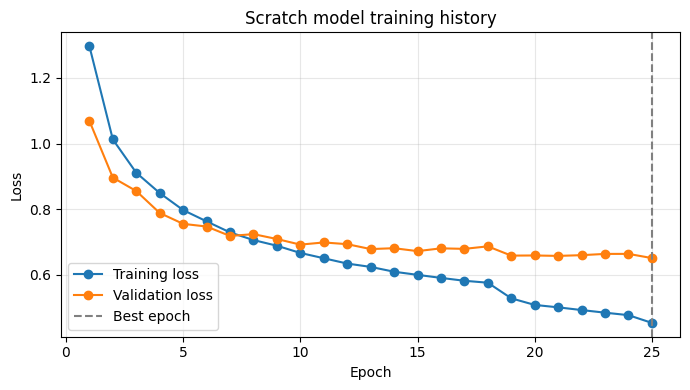

**Training result:** Epoch 25 had the lowest validation loss. The gap between training and validation loss shows some overfitting.

In [15]:
epoch_numbers = range(1, epochs_completed + 1)

plt.figure(figsize=(7, 4))
plt.plot(epoch_numbers, history["train_loss"], label="Training loss")
plt.plot(epoch_numbers, history["val_loss"], label="Validation loss")
plt.axvline(best_epoch, color="grey", linestyle="--", label="Best epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Scratch model training history")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

loss_gap = history["val_loss"][-1] - history["train_loss"][-1]
training_message = (
    "The gap between training and validation loss shows some overfitting."
    if loss_gap > 0.05
    else "There is no strong sign of overfitting."
)
display(Markdown(f"**Training result:** Epoch {best_epoch} had the lowest validation loss. {training_message}"))


## 7. Evaluation

Object detection needs class and box measurements, so normal accuracy is not used.

- **Precision:** correct predictions out of all predictions.
- **Recall:** detected objects out of all real objects.
- **F1:** balance of precision and recall.
- **IoU:** overlap between predicted and real boxes.

A prediction is correct when its class matches and IoU is at least 0.50.


In [16]:
def iou(box_a, box_b):
    x1 = max(box_a[0], box_b[0])
    y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2])
    y2 = min(box_a[3], box_b[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = max(0, box_a[2] - box_a[0]) * max(0, box_a[3] - box_a[1])
    area_b = max(0, box_b[2] - box_b[0]) * max(0, box_b[3] - box_b[1])
    union = area_a + area_b - intersection
    return intersection / union if union > 0 else 0.0


def decode_prediction(prediction):
    box_values = torch.sigmoid(prediction[0:4])
    object_values = torch.sigmoid(prediction[4])
    class_values = torch.softmax(prediction[5:], dim=0)
    boxes = []

    for grid_y in range(GRID_SIZE):
        for grid_x in range(GRID_SIZE):
            class_id = int(
                torch.argmax(class_values[:, grid_y, grid_x]).item()
            )
            score = float(
                (
                    object_values[grid_y, grid_x]
                    * class_values[class_id, grid_y, grid_x]
                ).item()
            )
            offset_x, offset_y, width, height = box_values[:, grid_y, grid_x].tolist()
            centre_x = (grid_x + offset_x) / GRID_SIZE
            centre_y = (grid_y + offset_y) / GRID_SIZE
            x1 = max(0.0, centre_x - width / 2)
            y1 = max(0.0, centre_y - height / 2)
            x2 = min(1.0, centre_x + width / 2)
            y2 = min(1.0, centre_y + height / 2)
            boxes.append([x1, y1, x2, y2, score, class_id])

    return boxes


def non_max_suppression(boxes, threshold=0.4):
    remaining = sorted(boxes, key=lambda box: box[4], reverse=True)
    kept = []

    while remaining:
        best = remaining.pop(0)
        kept.append(best)
        remaining = [
            box
            for box in remaining
            if box[5] != best[5] or iou(box[:4], best[:4]) < threshold
        ]

    return kept


def ground_truth_boxes(label_path):
    boxes, _ = read_yolo_label(label_path)
    return [
        [
            centre_x - width / 2,
            centre_y - height / 2,
            centre_x + width / 2,
            centre_y + height / 2,
            class_id,
        ]
        for class_id, centre_x, centre_y, width, height in boxes
    ]


In [17]:
def collect_predictions(model, dataset):
    collected = []
    model.eval()

    for index in range(len(dataset)):
        image_tensor, _ = dataset[index]
        _, label_path = dataset.pairs[index]

        with torch.no_grad():
            prediction = model(image_tensor.unsqueeze(0).to(device))[0].cpu()

        predicted_boxes = non_max_suppression(decode_prediction(prediction))
        actual_boxes = ground_truth_boxes(label_path)
        collected.append((predicted_boxes, actual_boxes))

    return collected


def calculate_metrics(collected, confidence=0.30, iou_threshold=0.50):
    true_positive = 0
    false_positive = 0
    false_negative = 0
    matched_ious = []

    for all_predictions, actual_boxes in collected:
        predicted_boxes = [
            box for box in all_predictions if box[4] >= confidence
        ]
        matched = set()

        for predicted_box in predicted_boxes:
            best_iou = 0.0
            best_index = -1

            for actual_index, actual_box in enumerate(actual_boxes):
                same_class = predicted_box[5] == actual_box[4]
                if actual_index in matched or not same_class:
                    continue

                overlap = iou(predicted_box[:4], actual_box[:4])
                if overlap > best_iou:
                    best_iou = overlap
                    best_index = actual_index

            if best_iou >= iou_threshold:
                true_positive += 1
                matched.add(best_index)
                matched_ious.append(best_iou)
            else:
                false_positive += 1

        false_negative += len(actual_boxes) - len(matched)

    precision = (
        true_positive / (true_positive + false_positive)
        if true_positive + false_positive
        else 0
    )
    recall = (
        true_positive / (true_positive + false_negative)
        if true_positive + false_negative
        else 0
    )
    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall
        else 0
    )

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mean_matched_iou": float(np.mean(matched_ious)) if matched_ious else 0.0,
        "true_positive": true_positive,
        "false_positive": false_positive,
        "false_negative": false_negative,
    }


In [18]:
print("Collecting validation predictions...")
validation_predictions = collect_predictions(model, val_dataset)

confidence_values = np.arange(0.20, 0.96, 0.05)
confidence_rows = []
for confidence in confidence_values:
    row = calculate_metrics(
        validation_predictions,
        confidence=float(confidence),
    )
    row["confidence"] = float(confidence)
    confidence_rows.append(row)

confidence_table = pd.DataFrame(confidence_rows)[
    ["confidence", "precision", "recall", "f1"]
]
display(confidence_table.round(4))

best_confidence_row = max(confidence_rows, key=lambda row: row["f1"])
best_confidence = best_confidence_row["confidence"]
print("Chosen confidence value:", round(best_confidence, 2))

print("Collecting test predictions...")
test_predictions = collect_predictions(model, test_dataset)
final_metrics = calculate_metrics(
    test_predictions,
    confidence=best_confidence,
)
display(pd.DataFrame([final_metrics]).round(4))


,confidence,precision,recall,f1
0,0.20,0.2348,0.4914,0.3178
1,0.25,0.2546,0.4888,0.3349
2,0.30,0.2710,0.4859,0.3479
3,0.35,0.2895,0.4834,0.3621
4,0.40,0.3066,0.4818,0.3747
5,0.45,0.3236,0.4795,0.3864
6,0.50,0.3418,0.4746,0.3974
7,0.55,0.3618,0.4710,0.4093
8,0.60,0.3833,0.4667,0.4209
9,0.65,0.4063,0.4608,0.4319


Chosen confidence value: 0.8


,precision,recall,f1,mean_matched_iou,true_positive,false_positive,false_negative
0,0.5302,0.4879,0.5082,0.6799,3880,3438,4073


## 8. Prediction samples

Solid boxes are labels. Red dashed boxes are predictions.


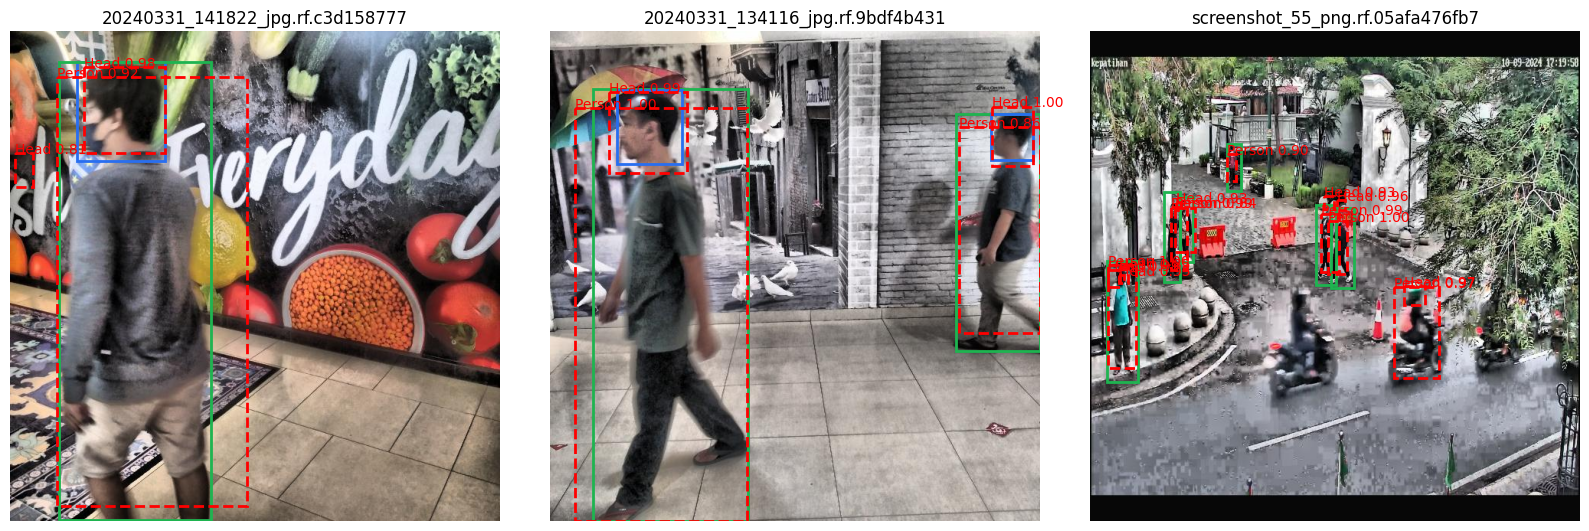

In [19]:
def plot_prediction(index, axis):
    image_path, _ = test_dataset.pairs[index]
    image = Image.open(image_path).convert("RGB")
    all_predictions, actual_boxes = test_predictions[index]
    predicted_boxes = [
        box for box in all_predictions if box[4] >= best_confidence
    ]

    axis.imshow(image)
    for x1, y1, x2, y2, class_id in actual_boxes:
        rectangle = plt.Rectangle(
            (x1 * image.width, y1 * image.height),
            (x2 - x1) * image.width,
            (y2 - y1) * image.height,
            fill=False,
            edgecolor=np.array(COLORS[class_id]) / 255,
            linewidth=2,
        )
        axis.add_patch(rectangle)

    for x1, y1, x2, y2, score, class_id in predicted_boxes:
        rectangle = plt.Rectangle(
            (x1 * image.width, y1 * image.height),
            (x2 - x1) * image.width,
            (y2 - y1) * image.height,
            fill=False,
            edgecolor="red",
            linewidth=2,
            linestyle="--",
        )
        axis.add_patch(rectangle)
        axis.text(
            x1 * image.width,
            y1 * image.height,
            f"{CLASS_NAMES[class_id]} {score:.2f}",
            color="red",
        )

    axis.set_title(image_path.name[:32])
    axis.axis("off")


figure, axes = plt.subplots(1, 3, figsize=(16, 6))
for axis, index in zip(axes, [0, 1, 2]):
    plot_prediction(index, axis)

plt.tight_layout()
plt.show()


In [20]:
display(Markdown(f"""
## 9. Final report

The model was tested on all {len(test_dataset)} test images using a confidence of {best_confidence:.2f}.

- Precision: **{final_metrics['precision']:.4f}**
- Recall: **{final_metrics['recall']:.4f}**
- F1 score: **{final_metrics['f1']:.4f}**
- Mean IoU: **{final_metrics['mean_matched_iou']:.4f}**

This is a useful scratch-model baseline, but crowded images are still difficult. A pretrained YOLO model could improve the results.

**Lesson learned:** Label quality and grid size strongly affect object-detection results.

**My contribution:** I checked the data, built and trained the scratch model, evaluated it, and explained the results.
"""))



## 9. Final report

The model was tested on all 846 test images using a confidence of 0.80.

- Precision: **0.5302**
- Recall: **0.4879**
- F1 score: **0.5082**
- Mean IoU: **0.6799**

This is a useful scratch-model baseline, but crowded images are still difficult. A pretrained YOLO model could improve the results.

**Lesson learned:** Label quality and grid size strongly affect object-detection results.

**My contribution:** I checked the data, built and trained the scratch model, evaluated it, and explained the results.
